# Foundations of Statistical Inference

Statistical inference is the process of generalizing from a **sample** to a **population**. It bridges the gap between what we observe (sample statistics) and the true reality (population parameters) using probability theory.

This notebook covers:
1. Sampling & Representation
2. Point Estimation
3. The Central Limit Theorem (CLT)
4. Interval Estimation
5. Python Implementation

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Sampling & Representation

Sampling is the foundation of inference. If the sample is biased, the inference will be invalid, regardless of the statistical rigor applied later.

### 1.1 Taxonomy of Sampling

**Probability Sampling:** Each element has a known non-zero probability of selection. Necessary for valid inference.

- **Simple Random Sampling (SRS):** Every combination of $n$ elements has an equal probability.
- **Stratified Sampling:** Ensures representation of subgroups (strata) by sampling from each independently.
- **Cluster Sampling:** Efficient for large geographical areas; samples whole groups (clusters).

**Non-Probability Sampling:** Convenience sampling; lacks theoretical justification for generalizing results.

In [3]:
# Create a synthetic population (N = 10,000)
population_size = 10000
population = np.random.normal(loc=100, scale=15, size=population_size)

population_mean = np.mean(population)
population_std = np.std(population, ddof=0)

print(f'Population Size: {population_size}')
print(f'Population Mean (μ): {population_mean:.2f}')
print(f'Population Std (σ): {population_std:.2f}')

Population Size: 10000
Population Mean (μ): 99.97
Population Std (σ): 15.05


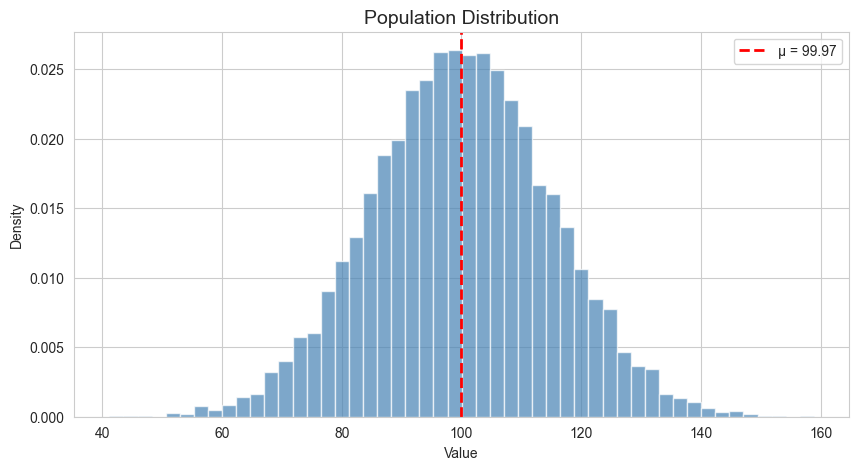

In [4]:
# Visualize the population distribution
plt.figure(figsize=(10, 5))
plt.hist(population, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
plt.axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'μ = {population_mean:.2f}')
plt.title('Population Distribution', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [5]:
# Demonstrate Simple Random Sampling (SRS)
sample_size = 100
srs_sample = np.random.choice(population, size=sample_size, replace=False)

srs_mean = np.mean(srs_sample)
srs_std = np.std(srs_sample, ddof=1)

print(f'Sample Size (n): {sample_size}')
print(f'Sample Mean (x̄): {srs_mean:.2f}')
print(f'Sample Std (s): {srs_std:.2f}')
print(f'\nDifference from population mean: {abs(srs_mean - population_mean):.4f}')

Sample Size (n): 100
Sample Mean (x̄): 101.75
Sample Std (s): 16.06

Difference from population mean: 1.7839


In [6]:
# Demonstrate Stratified Sampling
# Divide population into strata based on value ranges
strata_low = population[population < 90]
strata_mid = population[(population >= 90) & (population < 110)]
strata_high = population[population >= 110]

# Sample proportionally from each stratum
n_per_stratum = sample_size // 3
stratified_sample = np.concatenate([
    np.random.choice(strata_low, size=n_per_stratum, replace=False),
    np.random.choice(strata_mid, size=n_per_stratum, replace=False),
    np.random.choice(strata_high, size=n_per_stratum, replace=False)
])

strat_mean = np.mean(stratified_sample)
print(f'Stratified Sample Mean: {strat_mean:.2f}')
print(f'Difference from population mean: {abs(strat_mean - population_mean):.4f}')

Stratified Sample Mean: 98.94
Difference from population mean: 1.0303


In [7]:
# Compare SRS vs Stratified vs Convenience (first 100 elements)
convenience_sample = population[:sample_size]
conv_mean = np.mean(convenience_sample)

comparison = pd.DataFrame({
    'Method': ['Population', 'Simple Random', 'Stratified', 'Convenience'],
    'Mean': [population_mean, srs_mean, strat_mean, conv_mean],
    'Error': [0, abs(srs_mean-population_mean), abs(strat_mean-population_mean), abs(conv_mean-population_mean)]
})

print(comparison.to_string(index=False))

       Method       Mean    Error
   Population  99.967960 0.000000
Simple Random 101.751819 1.783858
   Stratified  98.937690 1.030270
  Convenience  98.442302 1.525658


## 2. Point Estimation

A point estimator is a rule (statistic) used to estimate a population parameter.

### Criteria for 'Good' Estimators:

- **Unbiasedness:** The sampling distribution of the estimator is centered at the true parameter ($E[\hat{\theta}] = \theta$).
- **Efficiency:** The estimator has the minimum possible variance among unbiased estimators.

In [8]:
# Demonstrate unbiasedness of sample mean
n_simulations = 10000
sample_size_demo = 50
sample_means = []

for _ in range(n_simulations):
    sample = np.random.choice(population, size=sample_size_demo, replace=False)
    sample_means.append(np.mean(sample))

mean_of_sample_means = np.mean(sample_means)
print(f'Population Mean (μ): {population_mean:.4f}')
print(f'Mean of Sample Means: {mean_of_sample_means:.4f}')
print(f'Difference: {abs(mean_of_sample_means - population_mean):.6f}')
print(f'\nThis demonstrates that E[x̄] ≈ μ (Unbiasedness)')

Population Mean (μ): 99.9680
Mean of Sample Means: 99.9496
Difference: 0.018327

This demonstrates that E[x̄] ≈ μ (Unbiasedness)


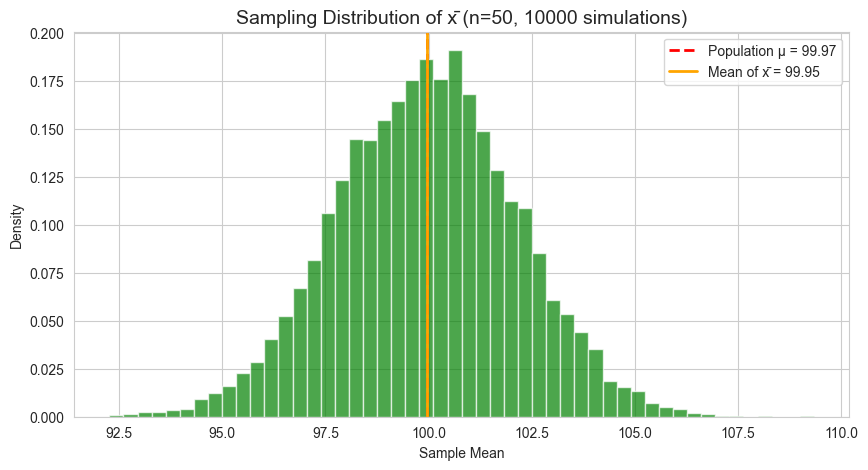

In [9]:
# Visualize the sampling distribution of the mean
plt.figure(figsize=(10, 5))
plt.hist(sample_means, bins=50, density=True, alpha=0.7, color='green', edgecolor='white')
plt.axvline(population_mean, color='red', linestyle='--', linewidth=2, label=f'Population μ = {population_mean:.2f}')
plt.axvline(mean_of_sample_means, color='orange', linestyle='-', linewidth=2, label=f'Mean of x̄ = {mean_of_sample_means:.2f}')
plt.title(f'Sampling Distribution of x̄ (n={sample_size_demo}, {n_simulations} simulations)', fontsize=14)
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.show()

## 3. The Central Limit Theorem (CLT)

The CLT is the bridge between raw data and the Normal Distribution. It asserts that for a sufficiently large sample size ($n \geq 30$), the sampling distribution of the sample mean $\bar{x}$ will be approximately Normal, **regardless of the population distribution shape**.

### Parameters of the Sampling Distribution:

- **Center:** Mean $\mu_{\bar{x}} = \mu$ (Population mean)
- **Spread:** Standard Error $SE = \frac{\sigma}{\sqrt{n}}$ (Standard deviation of the sampling distribution)

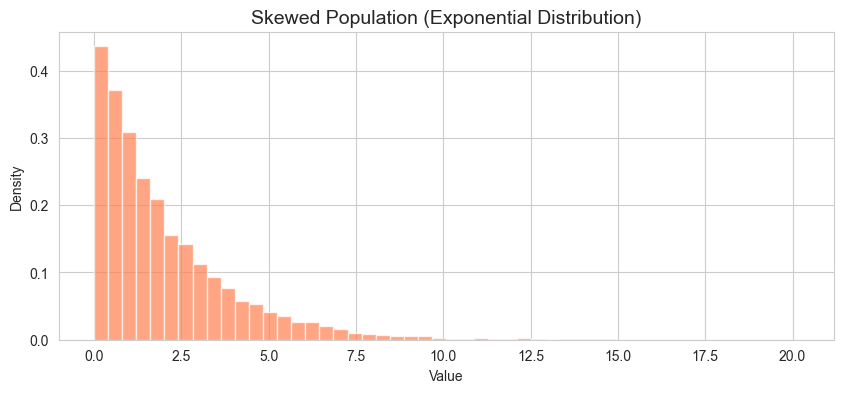

Population Mean: 2.02
Population Std: 1.99


In [10]:
# Create a highly skewed (non-normal) population
skewed_pop = np.random.exponential(scale=2, size=10000)

plt.figure(figsize=(10, 4))
plt.hist(skewed_pop, bins=50, density=True, alpha=0.7, color='coral')
plt.title('Skewed Population (Exponential Distribution)', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

print(f'Population Mean: {np.mean(skewed_pop):.2f}')
print(f'Population Std: {np.std(skewed_pop):.2f}')

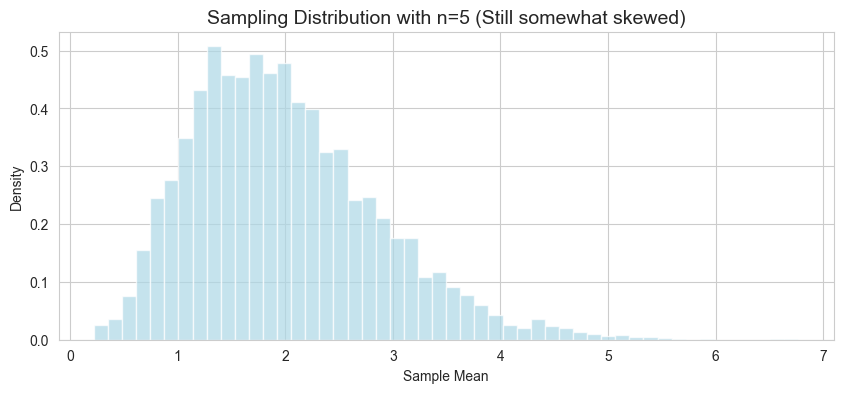

In [11]:
# CLT with small sample size (n=5)
n_small = 5
means_small = [np.mean(np.random.choice(skewed_pop, size=n_small)) for _ in range(5000)]

plt.figure(figsize=(10, 4))
plt.hist(means_small, bins=50, density=True, alpha=0.7, color='lightblue')
plt.title(f'Sampling Distribution with n={n_small} (Still somewhat skewed)', fontsize=14)
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.show()

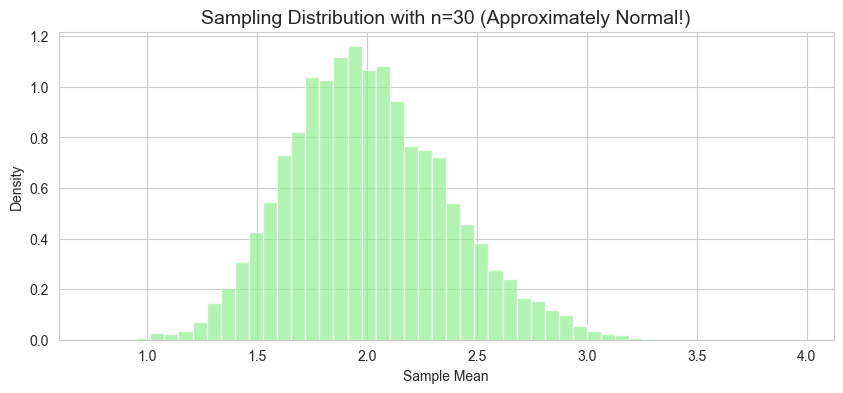

Mean of sample means: 2.0091
Standard Error (theoretical): 0.3632
Std of sample means: 0.3629


In [12]:
# CLT with large sample size (n=30) - CLT kicks in!
n_large = 30
means_large = [np.mean(np.random.choice(skewed_pop, size=n_large)) for _ in range(5000)]

plt.figure(figsize=(10, 4))
plt.hist(means_large, bins=50, density=True, alpha=0.7, color='lightgreen')
plt.title(f'Sampling Distribution with n={n_large} (Approximately Normal!)', fontsize=14)
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.show()

print(f'Mean of sample means: {np.mean(means_large):.4f}')
print(f'Standard Error (theoretical): {np.std(skewed_pop)/np.sqrt(n_large):.4f}')
print(f'Std of sample means: {np.std(means_large):.4f}')

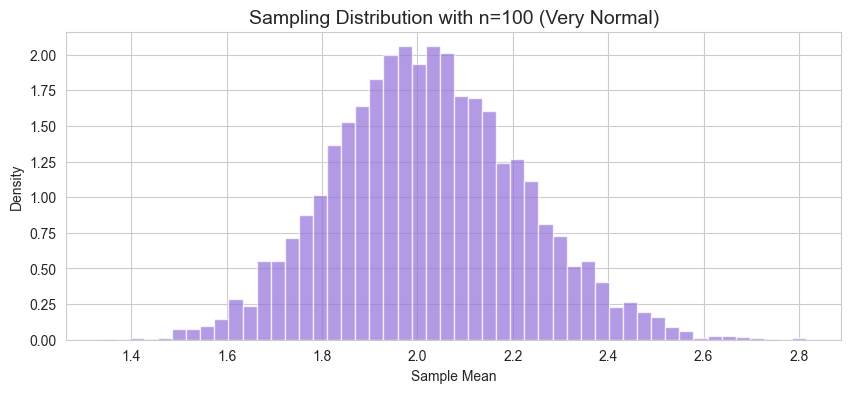

In [13]:
# CLT with n=100 - even more Normal
n_very_large = 100
means_vlarge = [np.mean(np.random.choice(skewed_pop, size=n_very_large)) for _ in range(5000)]

plt.figure(figsize=(10, 4))
plt.hist(means_vlarge, bins=50, density=True, alpha=0.7, color='mediumpurple')
plt.title(f'Sampling Distribution with n={n_very_large} (Very Normal)', fontsize=14)
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.show()

## 4. Interval Estimation

Point estimates are inherently imprecise. Confidence Intervals (CI) quantify this uncertainty by providing a range of plausible values for the parameter.

### 4.1 Confidence Interval Structure

$$\text{CI} = \text{Point Estimate} \pm (\text{Critical Value} \times \text{Standard Error})$$

### 4.2 Selection of Distribution

- **Z-Interval ($\sigma$ Known):** Used when population standard deviation is known. Uses Z-scores from Standard Normal.
- **T-Interval ($\sigma$ Unknown):** Used when population standard deviation is unknown (estimated by $s$). Uses t-distribution with fatter tails, especially at small sample sizes ($df = n-1$).

In [14]:
# Z-Interval Example (σ known)
np.random.seed(123)
sample_data = np.random.normal(loc=100, scale=15, size=50)

sample_mean = np.mean(sample_data)
pop_sigma = 15  # Known population standard deviation
n = len(sample_data)
confidence = 0.95

# Z-interval
z_critical = stats.norm.ppf(1 - (1 - confidence)/2)
z_margin_error = z_critical * (pop_sigma / np.sqrt(n))
z_ci_lower = sample_mean - z_margin_error
z_ci_upper = sample_mean + z_margin_error

print(f'Sample Mean: {sample_mean:.2f}')
print(f'Z-Critical Value (95%): {z_critical:.4f}')
print(f'Standard Error: {pop_sigma/np.sqrt(n):.4f}')
print(f'Margin of Error: {z_margin_error:.4f}')
print(f'95% Z-Confidence Interval: [{z_ci_lower:.2f}, {z_ci_upper:.2f}]')

Sample Mean: 100.20
Z-Critical Value (95%): 1.9600
Standard Error: 2.1213
Margin of Error: 4.1577
95% Z-Confidence Interval: [96.04, 104.36]


In [15]:
# T-Interval Example (σ unknown - more realistic)
sample_std = np.std(sample_data, ddof=1)  # Sample standard deviation
df = n - 1  # degrees of freedom

# T-interval
t_critical = stats.t.ppf(1 - (1 - confidence)/2, df=df)
t_margin_error = t_critical * (sample_std / np.sqrt(n))
t_ci_lower = sample_mean - t_margin_error
t_ci_upper = sample_mean + t_margin_error

print(f'Sample Mean: {sample_mean:.2f}')
print(f'Sample Std (s): {sample_std:.4f}')
print(f'T-Critical Value (95%, df={df}): {t_critical:.4f}')
print(f'Standard Error: {sample_std/np.sqrt(n):.4f}')
print(f'Margin of Error: {t_margin_error:.4f}')
print(f'95% T-Confidence Interval: [{t_ci_lower:.2f}, {t_ci_upper:.2f}]')

Sample Mean: 100.20
Sample Std (s): 18.0255
T-Critical Value (95%, df=49): 2.0096
Standard Error: 2.5492
Margin of Error: 5.1228
95% T-Confidence Interval: [95.08, 105.32]


In [16]:
# Compare Z and T critical values across sample sizes
sample_sizes = [5, 10, 20, 30, 50, 100, 1000]
z_crit = stats.norm.ppf(0.975)

comparison_data = []
for sz in sample_sizes:
    t_crit = stats.t.ppf(0.975, df=sz-1)
    comparison_data.append({
        'n': sz,
        'Z-critical': round(z_crit, 4),
        'T-critical': round(t_crit, 4),
        'Difference': round(t_crit - z_crit, 4)
    })

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))
print(f'\nNote: As n increases, t-distribution approaches normal distribution.')

   n  Z-critical  T-critical  Difference
   5        1.96      2.7764      0.8165
  10        1.96      2.2622      0.3022
  20        1.96      2.0930      0.1331
  30        1.96      2.0452      0.0853
  50        1.96      2.0096      0.0496
 100        1.96      1.9842      0.0243
1000        1.96      1.9623      0.0024

Note: As n increases, t-distribution approaches normal distribution.


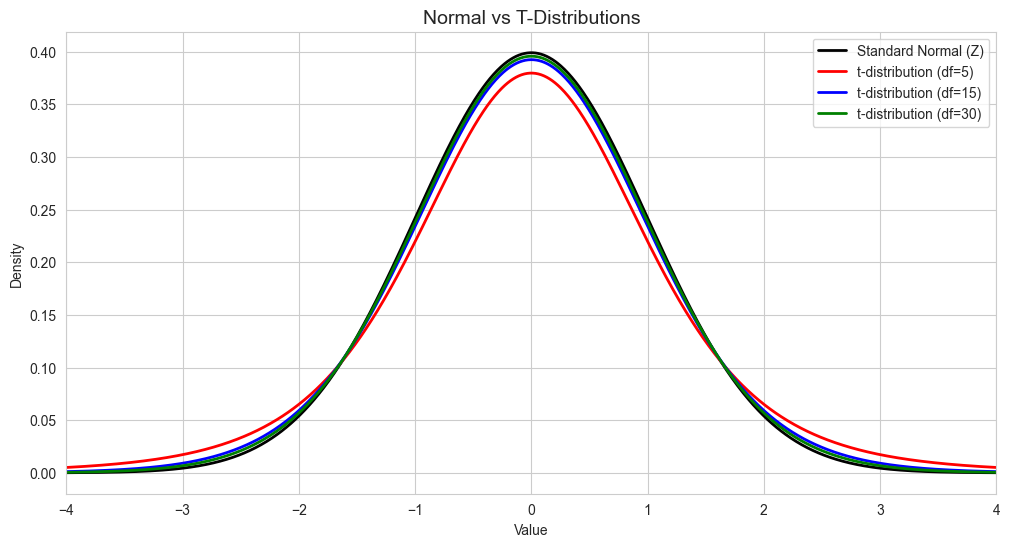

In [17]:
# Visualize Normal vs T-distribution for different df
x = np.linspace(-4, 4, 1000)
y_norm = stats.norm.pdf(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y_norm, 'k-', linewidth=2, label='Standard Normal (Z)')

colors = ['red', 'blue', 'green']
dfs = [5, 15, 30]

for df_val, color in zip(dfs, colors):
    y_t = stats.t.pdf(x, df=df_val)
    plt.plot(x, y_t, color=color, linewidth=2, label=f't-distribution (df={df_val})')

plt.title('Normal vs T-Distributions', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.xlim(-4, 4)
plt.show()

### 4.3 The 'Net Fishing' Interpretation

A 95% confidence interval does **NOT** mean there is a 95% probability that the true parameter $\mu$ is in *your* specific interval.

It means that if you were to repeat the sampling process 100 times, 95 of those intervals would capture the true population mean.

**The confidence is in the procedure, not the specific outcome.**

In [18]:
# Demonstrate: 95% of CIs capture the true mean
n_experiments = 100
sample_size_ci = 50
true_mean = 100
true_sigma = 15

captured = 0
intervals = []

for i in range(n_experiments):
    sample = np.random.normal(loc=true_mean, scale=true_sigma, size=sample_size_ci)
    mean = np.mean(sample)
    sem = stats.sem(sample)
    ci = stats.t.interval(0.95, df=sample_size_ci-1, loc=mean, scale=sem)
    intervals.append((mean, ci[0], ci[1]))
    if ci[0] <= true_mean <= ci[1]:
        captured += 1

print(f'Experiments run: {n_experiments}')
print(f'Intervals capturing true mean (100): {captured}')
print(f'Capture rate: {captured/n_experiments*100:.1f}%')

Experiments run: 100
Intervals capturing true mean (100): 94
Capture rate: 94.0%


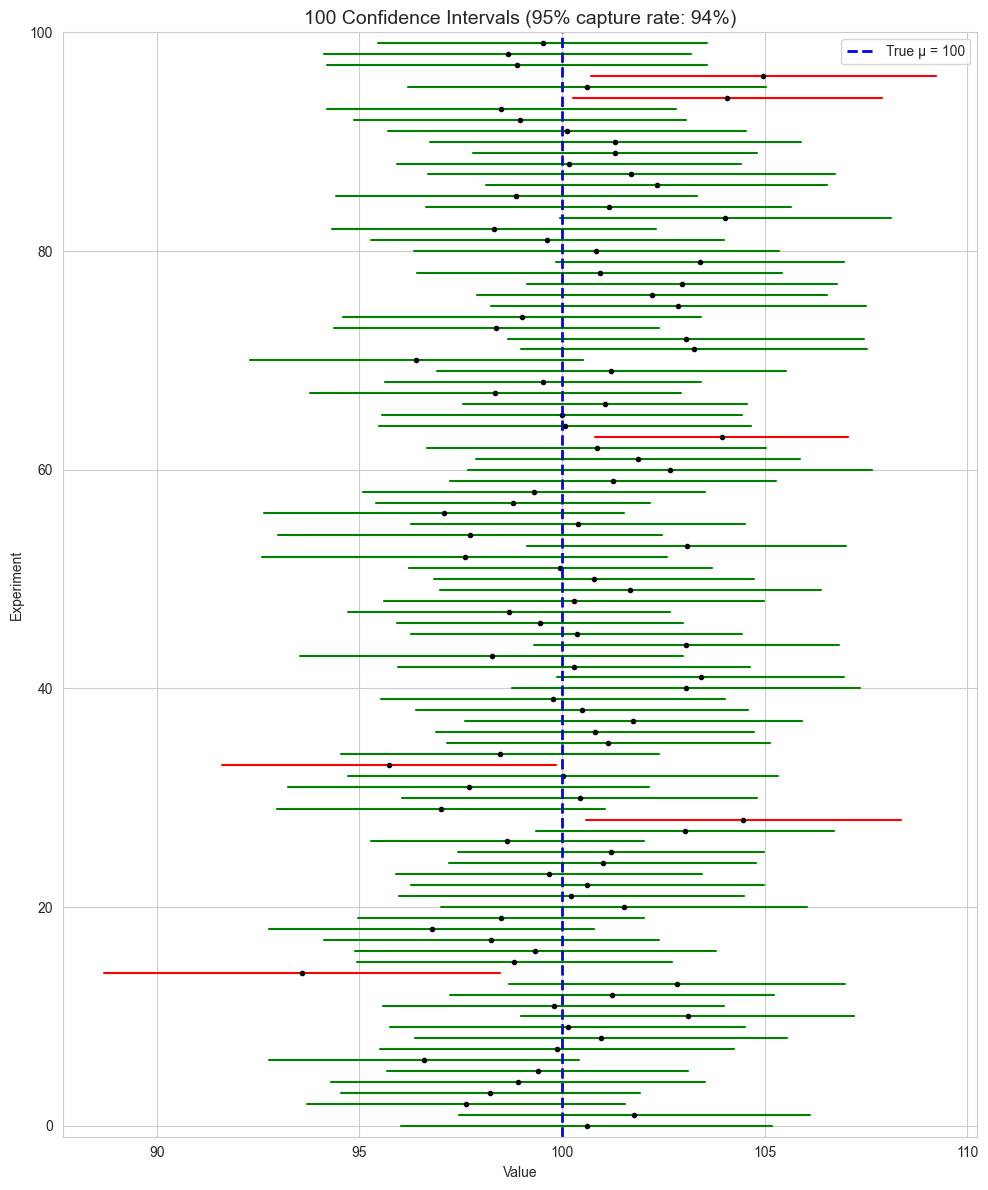

Green = Captures true mean | Red = Misses true mean


In [19]:
# Visualize 100 confidence intervals
plt.figure(figsize=(10, 12))

for i, (mean, lower, upper) in enumerate(intervals):
    color = 'green' if lower <= true_mean <= upper else 'red'
    plt.plot([lower, upper], [i, i], color=color, linewidth=1.5)
    plt.plot(mean, i, 'ko', markersize=3)

plt.axvline(true_mean, color='blue', linestyle='--', linewidth=2, label=f'True μ = {true_mean}')
plt.xlabel('Value')
plt.ylabel('Experiment')
plt.title(f'100 Confidence Intervals (95% capture rate: {captured}%)', fontsize=14)
plt.legend()
plt.ylim(-1, n_experiments)
plt.tight_layout()
plt.show()

print('Green = Captures true mean | Red = Misses true mean')

## 5. Complete Python Implementation

Here is a complete, reusable function for calculating confidence intervals.

In [20]:
def calculate_ci(data, confidence=0.95, pop_std=None):
    """
    Calculate confidence interval for the mean.
    
    Parameters:
    -----------
    data : array-like
        Sample data
    confidence : float
        Confidence level (default 0.95)
    pop_std : float, optional
        Population standard deviation. If None, uses t-distribution.
    
    Returns:
    --------
    dict : Contains mean, margin of error, and confidence interval
    """
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)
    
    if pop_std is not None:
        # Z-interval
        sem = pop_std / np.sqrt(n)
        crit = stats.norm.ppf(1 - (1 - confidence)/2)
        method = 'Z-interval (σ known)'
    else:
        # T-interval
        sem = stats.sem(data)
        crit = stats.t.ppf(1 - (1 - confidence)/2, df=n-1)
        method = 'T-interval (σ unknown)'
    
    margin = crit * sem
    ci_lower = mean - margin
    ci_upper = mean + margin
    
    return {
        'method': method,
        'mean': mean,
        'n': n,
        'confidence': confidence,
        'critical_value': crit,
        'standard_error': sem,
        'margin_of_error': margin,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'ci': (ci_lower, ci_upper)
    }

# Test the function
test_data = np.random.normal(100, 15, 50)
result = calculate_ci(test_data)
for key, value in result.items():
    print(f'{key}: {value}')

method: T-interval (σ unknown)
mean: 99.4279207532909
n: 50
confidence: 0.95
critical_value: 2.0095752371292392
standard_error: 2.126034011102893
margin_of_error: 4.272425302006924
ci_lower: 95.15549545128398
ci_upper: 103.70034605529783
ci: (np.float64(95.15549545128398), np.float64(103.70034605529783))


## Summary of Statistical Tools

| Scenario | Estimator | Statistic | Distribution |
|----------|-----------|-----------|--------------|
| $\sigma$ Known | Mean | $Z = \frac{\bar{x} - \mu}{\sigma/\sqrt{n}}$ | Normal ($Z$) |
| $\sigma$ Unknown | Mean | $t = \frac{\bar{x} - \mu}{s/\sqrt{n}}$ | Student's $t$ |

### Key Takeaways:
1. **Sampling matters** - Probability sampling is required for valid inference
2. **CLT is powerful** - Sample means become Normal regardless of population shape (n ≥ 30)
3. **Use T when σ is unknown** - T-distribution accounts for extra uncertainty
4. **CI interpretation** - Confidence is in the procedure, not a specific interval

## Exercise

Try the following:
1. Generate a sample from a different distribution (e.g., uniform, binomial)
2. Calculate a 99% confidence interval
3. Verify the CLT holds by increasing sample size
4. Compare Z-interval vs T-interval for small samples

## 1. Generate a Sample from a Different Distribution

## Uniform Distribution

Sample Mean: 49.6827630884058
Sample Std Dev: 28.46564342818238


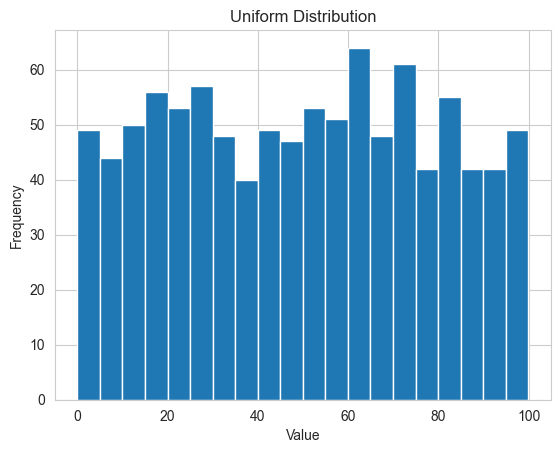

In [22]:
# Generate a sample from Uniform Distribution
uniform_sample = np.random.uniform(
    low=0,
    high=100,
    size=1000
)

print("Sample Mean:", np.mean(uniform_sample))
print("Sample Std Dev:", np.std(uniform_sample))

plt.hist(uniform_sample, bins=20)
plt.title("Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

## Binomial Distribution

Sample Mean: 4.975
Sample Std Dev: 1.604485898972004


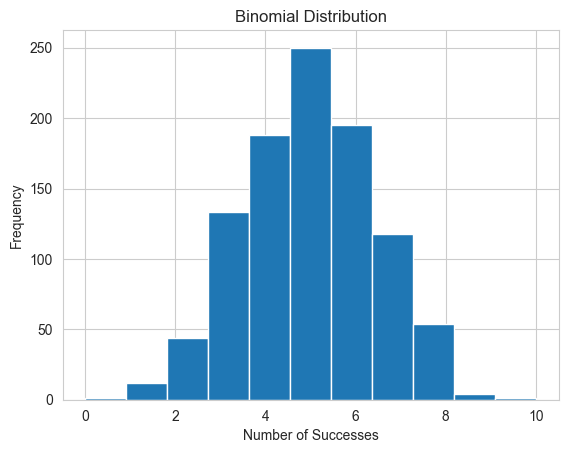

In [23]:
# Generate a sample from Binomial Distribution
binomial_sample = np.random.binomial(
    n=10,
    p=0.5,
    size=1000
)

print("Sample Mean:", np.mean(binomial_sample))
print("Sample Std Dev:", np.std(binomial_sample))

plt.hist(binomial_sample, bins=11)
plt.title("Binomial Distribution")
plt.xlabel("Number of Successes")
plt.ylabel("Frequency")
plt.show()

### 2. Calculate a 99% Confidence Interval

In [24]:
# Generate sample data
sample = np.random.normal(
    loc=50,
    scale=10,
    size=100
)

# Sample statistics
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
n = len(sample)

# 99% Z critical value
z_critical = stats.norm.ppf(0.995)

# Margin of Error
margin_error = z_critical * (sample_std / np.sqrt(n))

# Confidence Interval
lower_bound = sample_mean - margin_error
upper_bound = sample_mean + margin_error

print("Sample Mean:", sample_mean)
print("99% Confidence Interval:")
print(lower_bound, "to", upper_bound)

Sample Mean: 50.1220586338111
99% Confidence Interval:
47.4360320958874 to 52.8080851717348


### 3. Verify CLT by Increasing Sample Size

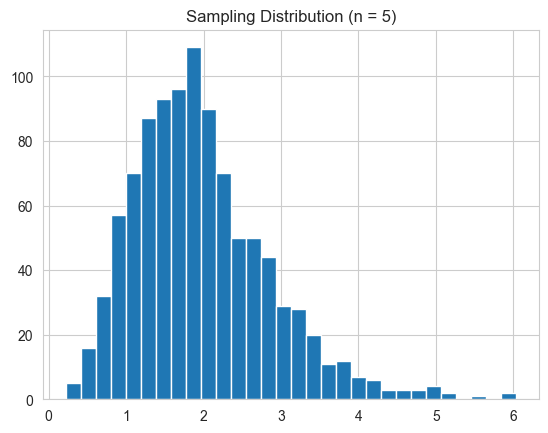

In [25]:
# Population: Exponential Distribution
population = np.random.exponential(
    scale=2,
    size=100000
)

# Sample Size = 5
sample_means_5 = []

for i in range(1000):
    sample = np.random.choice(population, size=5)
    sample_means_5.append(np.mean(sample))

plt.hist(sample_means_5, bins=30)
plt.title("Sampling Distribution (n = 5)")
plt.show()

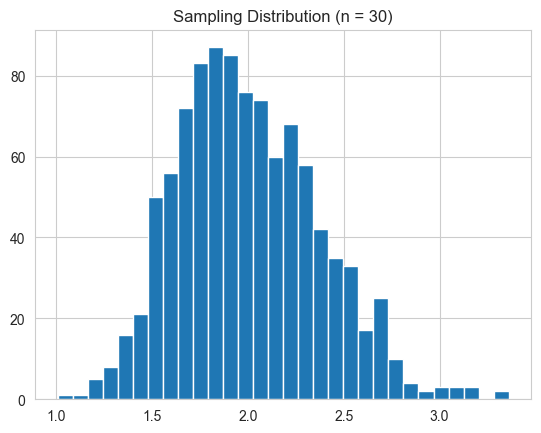

In [26]:
# Sample Size = 30
sample_means_30 = []

for i in range(1000):
    sample = np.random.choice(population, size=30)
    sample_means_30.append(np.mean(sample))

plt.hist(sample_means_30, bins=30)
plt.title("Sampling Distribution (n = 30)")
plt.show()

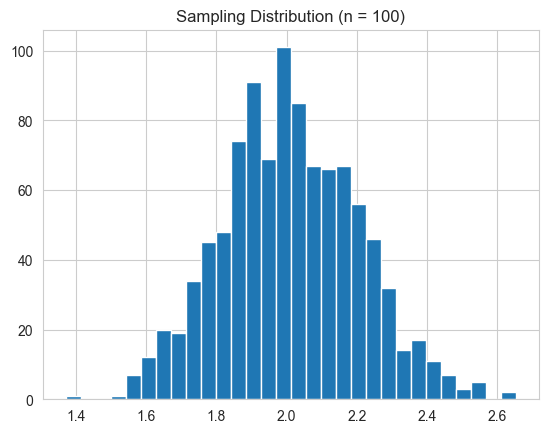

In [27]:
# Sample Size = 100
sample_means_100 = []

for i in range(1000):
    sample = np.random.choice(population, size=100)
    sample_means_100.append(np.mean(sample))

plt.hist(sample_means_100, bins=30)
plt.title("Sampling Distribution (n = 100)")
plt.show()

## 4. Compare Z-Interval vs T-Interval for Small Samples

In [28]:
# Small sample
sample = np.random.normal(
    loc=50,
    scale=10,
    size=10
)

sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
n = len(sample)

# Z Interval
z_critical = stats.norm.ppf(0.975)

z_margin = z_critical * (sample_std / np.sqrt(n))

z_lower = sample_mean - z_margin
z_upper = sample_mean + z_margin

# T Interval
t_critical = stats.t.ppf(
    0.975,
    df=n-1
)

t_margin = t_critical * (sample_std / np.sqrt(n))

t_lower = sample_mean - t_margin
t_upper = sample_mean + t_margin

print("Sample Mean:", sample_mean)

print("\nZ Interval:")
print(z_lower, "to", z_upper)

print("\nT Interval:")
print(t_lower, "to", t_upper)

Sample Mean: 47.022307725877376

Z Interval:
38.17545914958214 to 55.86915630217261

T Interval:
36.811425264303054 to 57.2331901874517
